In [71]:
import numpy as np              # calcul numérique (tableaux, opérations mathématiques)
import pandas as pd             # manipulation de tables de données (DataFrames)
import matplotlib.pyplot as plt # tracé de graphiques
import seaborn as sns           # graphiques plus jolis, basés sur matplotlib

# Prétraitement des données
from sklearn.preprocessing import StandardScaler   # pour standardiser (z-score) les colonnes

# Réduction de dimension
from sklearn.decomposition import PCA               # Analyse en Composantes Principales (visualisation 2D)

# Algorithmes de clustering
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Métriques pour évaluer la qualité des clusters
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score

# Outils pour la CAH (dendrogramme, découpe de l'arbre)
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

# Style des graphiques (fond gris clair avec grille, plus lisible)
sns.set_style("whitegrid")

# Graine aléatoire fixe : garantit que si on relance le code, on obtient EXACTEMENT
# les mêmes résultats (K-means et GMM utilisent de l'aléatoire au départ)
RANDOM_STATE = 42

In [72]:
import os
# On regarde à l'intérieur du sous-dossier imbriqué
print(os.listdir("data/hhblock_dataset/hhblock_dataset"))

['block_0.csv', 'block_1.csv', 'block_10.csv', 'block_100.csv', 'block_101.csv', 'block_102.csv', 'block_103.csv', 'block_104.csv', 'block_105.csv', 'block_106.csv', 'block_107.csv', 'block_108.csv', 'block_109.csv', 'block_11.csv', 'block_110.csv', 'block_111.csv', 'block_12.csv', 'block_13.csv', 'block_14.csv', 'block_15.csv', 'block_16.csv', 'block_17.csv', 'block_18.csv', 'block_19.csv', 'block_2.csv', 'block_20.csv', 'block_21.csv', 'block_22.csv', 'block_23.csv', 'block_24.csv', 'block_25.csv', 'block_26.csv', 'block_27.csv', 'block_28.csv', 'block_29.csv', 'block_3.csv', 'block_30.csv', 'block_31.csv', 'block_32.csv', 'block_33.csv', 'block_34.csv', 'block_35.csv', 'block_36.csv', 'block_37.csv', 'block_38.csv', 'block_39.csv', 'block_4.csv', 'block_40.csv', 'block_41.csv', 'block_42.csv', 'block_43.csv', 'block_44.csv', 'block_45.csv', 'block_46.csv', 'block_47.csv', 'block_48.csv', 'block_49.csv', 'block_5.csv', 'block_50.csv', 'block_51.csv', 'block_52.csv', 'block_53.csv', '

In [73]:
df_test = pd.read_csv("data/hhblock_dataset/hhblock_dataset/block_0.csv")

print(df_test.shape)

print(df_test.columns.tolist())

df_test.head()

(25286, 50)
['LCLid', 'day', 'hh_0', 'hh_1', 'hh_2', 'hh_3', 'hh_4', 'hh_5', 'hh_6', 'hh_7', 'hh_8', 'hh_9', 'hh_10', 'hh_11', 'hh_12', 'hh_13', 'hh_14', 'hh_15', 'hh_16', 'hh_17', 'hh_18', 'hh_19', 'hh_20', 'hh_21', 'hh_22', 'hh_23', 'hh_24', 'hh_25', 'hh_26', 'hh_27', 'hh_28', 'hh_29', 'hh_30', 'hh_31', 'hh_32', 'hh_33', 'hh_34', 'hh_35', 'hh_36', 'hh_37', 'hh_38', 'hh_39', 'hh_40', 'hh_41', 'hh_42', 'hh_43', 'hh_44', 'hh_45', 'hh_46', 'hh_47']


,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
0,MAC000002,2012-10-13,0.263,0.269,0.275,0.256,0.211,0.136,0.161,0.119,...,0.918,0.278,0.267,0.239,0.230,0.233,0.235,0.188,0.259,0.250
1,MAC000002,2012-10-14,0.262,0.166,0.226,0.088,0.126,0.082,0.123,0.083,...,1.075,0.956,0.821,0.745,0.712,0.511,0.231,0.210,0.278,0.159
2,MAC000002,2012-10-15,0.192,0.097,0.141,0.083,0.132,0.070,0.130,0.074,...,1.164,0.249,0.225,0.258,0.260,0.334,0.299,0.236,0.241,0.237
3,MAC000002,2012-10-16,0.237,0.237,0.193,0.118,0.098,0.107,0.094,0.109,...,0.966,0.172,0.192,0.228,0.203,0.211,0.188,0.213,0.157,0.202
4,MAC000002,2012-10-17,0.157,0.211,0.155,0.169,0.101,0.117,0.084,0.118,...,0.223,0.075,0.230,0.208,0.265,0.377,0.327,0.277,0.288,0.256


In [74]:
# Chemin vers le dossier contenant tous les blocks
HHBLOCK_DIR = "data/hhblock_dataset/hhblock_dataset"

# On liste tous les fichiers du dossier, et on garde seulement ceux qui finissent par ".csv"
# (au cas où il y aurait d'autres fichiers cachés dans le dossier)
block_files = [f for f in os.listdir(HHBLOCK_DIR) if f.endswith(".csv")]

# sorted() trie la liste par ordre alphabétique (pas indispensable, mais plus propre)
block_files = sorted(block_files)

print(f"{len(block_files)} fichiers block_*.csv trouvés")

# Liste vide qui va contenir chaque DataFrame (un par fichier block)
dfs = []

for f in block_files:
    # os.path.join construit le chemin complet : dossier + "/" + nom du fichier
    chemin_complet = os.path.join(HHBLOCK_DIR, f)
    
    # On charge le fichier et on l'ajoute à la liste
    df_block = pd.read_csv(chemin_complet)
    dfs.append(df_block)

# pd.concat empile tous les DataFrames de la liste les uns sous les autres
# ignore_index=True : on ne garde pas les anciens numéros de ligne, on repart de 0
df_hh = pd.concat(dfs, ignore_index=True)

# Vérification : nombre total de lignes et colonnes après empilement
print(df_hh.shape)
df_hh.head()

112 fichiers block_*.csv trouvés
(3469352, 50)


,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
0,MAC000002,2012-10-13,0.263,0.269,0.275,0.256,0.211,0.136,0.161,0.119,...,0.918,0.278,0.267,0.239,0.230,0.233,0.235,0.188,0.259,0.250
1,MAC000002,2012-10-14,0.262,0.166,0.226,0.088,0.126,0.082,0.123,0.083,...,1.075,0.956,0.821,0.745,0.712,0.511,0.231,0.210,0.278,0.159
2,MAC000002,2012-10-15,0.192,0.097,0.141,0.083,0.132,0.070,0.130,0.074,...,1.164,0.249,0.225,0.258,0.260,0.334,0.299,0.236,0.241,0.237
3,MAC000002,2012-10-16,0.237,0.237,0.193,0.118,0.098,0.107,0.094,0.109,...,0.966,0.172,0.192,0.228,0.203,0.211,0.188,0.213,0.157,0.202
4,MAC000002,2012-10-17,0.157,0.211,0.155,0.169,0.101,0.117,0.084,0.118,...,0.223,0.075,0.230,0.208,0.265,0.377,0.327,0.277,0.288,0.256


In [75]:

df_hh["day"] = pd.to_datetime(df_hh["day"])

print(df_hh["day"].dtype)

print("Première date :", df_hh["day"].min())
print("Dernière date :", df_hh["day"].max())

datetime64[ns]
Première date : 2011-11-24 00:00:00
Dernière date : 2014-02-27 00:00:00


In [76]:
df_hh["year_month"] = df_hh["day"].dt.to_period("M")

jours_par_foyer_mois = df_hh.groupby(["LCLid", "year_month"])["day"].nunique()

mois_a_tester = ["2011-11", "2011-12", "2012-01", "2012-02", "2012-03", "2012-04", "2012-05", "2012-06", "2012-07", "2012-08", "2012-09", "2012-10", "2012-11", "2012-12", "2013-01", "2013-02", "2013-03", "2013-04", "2013-05", "2013-06", "2013-07", "2013-08", "2013-09", "2013-10", "2013-11", "2013-12", "2014-01", "2014-02"]

for mois in mois_a_tester:
    
    nb_jours_attendus = pd.Period(mois).days_in_month
    
    
    sous_ensemble = jours_par_foyer_mois[jours_par_foyer_mois.index.get_level_values("year_month") == mois]
    
    nb_foyers_complets = (sous_ensemble == nb_jours_attendus).sum()
    nb_foyers_total = sous_ensemble.shape[0]
    
    print(f"{mois} : {nb_foyers_complets}/{nb_foyers_total} foyers complets "
          f"({100*nb_foyers_complets/nb_foyers_total:.1f}%)")

2011-11 : 0/63 foyers complets (0.0%)
2011-12 : 72/411 foyers complets (17.5%)
2012-01 : 356/567 foyers complets (62.8%)
2012-02 : 491/828 foyers complets (59.3%)
2012-03 : 755/1231 foyers complets (61.3%)
2012-04 : 1013/2035 foyers complets (49.8%)
2012-05 : 1487/3617 foyers complets (41.1%)
2012-06 : 2229/4201 foyers complets (53.1%)
2012-07 : 3526/4749 foyers complets (74.2%)
2012-08 : 4080/4764 foyers complets (85.6%)
2012-09 : 4300/5007 foyers complets (85.9%)
2012-10 : 4062/5521 foyers complets (73.6%)
2012-11 : 4864/5534 foyers complets (87.9%)
2012-12 : 4319/5537 foyers complets (78.0%)
2013-01 : 4708/5515 foyers complets (85.4%)
2013-02 : 4701/5490 foyers complets (85.6%)
2013-03 : 4672/5442 foyers complets (85.9%)
2013-04 : 4520/5409 foyers complets (83.6%)
2013-05 : 4667/5380 foyers complets (86.7%)
2013-06 : 4748/5357 foyers complets (88.6%)
2013-07 : 4338/5341 foyers complets (81.2%)
2013-08 : 4564/5294 foyers complets (86.2%)
2013-09 : 4735/5254 foyers complets (90.1%)
20

## Justification du choix du mois — Janvier 2013

Janvier 2013 fait partie des mois les plus complets du dataset (**85.4%** des foyers avec leurs 31 jours renseignés, contre 78% à 90.1% selon les mois testés). C'est un mois hivernal froid (température min. moyenne : 2.6°C), ce qui rend le signal "chauffage électrique" bien visible dans les courbes de charge. Il est situé en 2013, année où le tarif dynamique dToU était actif, permettant un croisement pertinent profils × tarif. Un seul jour férié tombe en janvier (1er janvier), facilement isolé du calcul de la journée moyenne. Février 2013 (météo et complétude comparables) est retenu comme second mois pour le test de stabilité des clusters.

In [77]:
MOIS_CHOISI = "2013-01"  

periode = pd.Period(MOIS_CHOISI)
PERIOD_START = periode.start_time  
PERIOD_END = periode.end_time     

n_jours_attendus = periode.days_in_month
print(f"Mois choisi : {MOIS_CHOISI} — {n_jours_attendus} jours attendus")

df_periode = df_hh[(df_hh["day"] >= PERIOD_START) & (df_hh["day"] <= PERIOD_END)].copy()

print(f"Lignes dans la période : {df_periode.shape[0]}")


Mois choisi : 2013-01 — 31 jours attendus
Lignes dans la période : 169565


In [78]:
df_periode.head()

,LCLid,day,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,...,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47,year_month
76,MAC000002,2013-01-01,0.219,0.241,0.191,0.235,0.182,0.229,0.194,0.201,...,0.209,0.886,0.573,0.250,0.292,0.231,0.281,0.253,0.258,2013-01
77,MAC000002,2013-01-02,0.253,0.211,0.347,0.280,0.261,0.229,0.258,0.125,...,0.215,0.640,0.588,0.254,0.236,0.269,0.268,0.245,0.255,2013-01
78,MAC000002,2013-01-03,0.196,0.239,0.235,0.195,0.239,0.201,0.206,0.133,...,0.243,0.265,1.098,0.256,0.218,0.247,0.276,0.238,0.286,2013-01
79,MAC000002,2013-01-04,0.257,0.263,0.296,0.284,0.241,0.246,0.244,0.254,...,0.242,0.662,0.601,0.226,0.228,0.227,0.176,0.252,0.198,2013-01
80,MAC000002,2013-01-05,0.195,0.208,0.171,0.226,0.188,0.207,0.210,0.114,...,0.228,0.184,0.222,0.289,0.232,0.285,0.251,0.270,0.282,2013-01


In [79]:

compte_jours_par_foyer = df_periode.groupby("LCLid")["day"].nunique()

foyers_complets = compte_jours_par_foyer[compte_jours_par_foyer == n_jours_attendus].index

foyers_incomplets = compte_jours_par_foyer[compte_jours_par_foyer != n_jours_attendus].index

print(f"Foyers présents sur la période : {len(compte_jours_par_foyer)}")
print(f"Foyers COMPLETS ({n_jours_attendus}/{n_jours_attendus} jours) : {len(foyers_complets)}")
print(f"Foyers EXCLUS (incomplets) : {len(foyers_incomplets)} "
      f"({100*len(foyers_incomplets)/len(compte_jours_par_foyer):.1f}% du total)")

df_complete = df_periode[df_periode["LCLid"].isin(foyers_complets)].copy()

df_complete = df_complete.sort_values(["LCLid", "day"]).reset_index(drop=True)

print(f"\nDataset final : {df_complete['LCLid'].nunique()} foyers, {df_complete.shape[0]} lignes")

Foyers présents sur la période : 5515
Foyers COMPLETS (31/31 jours) : 4708
Foyers EXCLUS (incomplets) : 807 (14.6% du total)

Dataset final : 4708 foyers, 145948 lignes


In [80]:
hh_cols = [f"hh_{i}" for i in range(48)]

print("Valeurs manquantes (NaN) :", df_complete[hh_cols].isna().sum().sum())

print("Valeurs négatives :", (df_complete[hh_cols] < 0).sum().sum())

Valeurs manquantes (NaN) : 0
Valeurs négatives : 0


In [81]:
hh_cols = [f"hh_{i}" for i in range(48)]

mean_curves = df_complete.groupby("LCLid")[hh_cols].mean()

print(mean_curves.shape)

mean_curves.head()

(4708, 48)


,hh_0,hh_1,hh_2,hh_3,hh_4,hh_5,hh_6,hh_7,hh_8,hh_9,...,hh_38,hh_39,hh_40,hh_41,hh_42,hh_43,hh_44,hh_45,hh_46,hh_47
LCLid,,,,,,,,,,,,,,,,,,,,,
MAC000002,0.230097,0.239194,0.233871,0.222677,0.201871,0.176774,0.146806,0.121968,0.113323,0.109161,...,0.329516,0.392484,0.886000,0.390516,0.293258,0.326387,0.339839,0.354000,0.297935,0.269419
MAC000003,2.633161,2.574387,2.490645,2.035226,1.926742,1.908548,1.969677,1.895677,2.033581,1.846355,...,0.200258,0.164226,0.184226,0.184000,0.176871,0.159258,0.164065,0.192129,0.182581,0.143516
MAC000004,0.027742,0.044258,0.041581,0.018290,0.037581,0.049032,0.034194,0.050484,0.017581,0.022194,...,0.035032,0.041226,0.048419,0.032968,0.024677,0.049161,0.050032,0.042323,0.023194,0.041774
MAC000005,0.049516,0.036774,0.031710,0.030194,0.030355,0.030516,0.030516,0.030290,0.030355,0.029806,...,0.218000,0.192290,0.153903,0.131968,0.149000,0.188161,0.201677,0.189032,0.125968,0.085677
MAC000006,0.033065,0.029903,0.025581,0.021000,0.021323,0.021613,0.020032,0.021839,0.020548,0.022355,...,0.098516,0.095613,0.088484,0.094290,0.073839,0.056839,0.050677,0.055161,0.038742,0.045323


In [82]:
X = mean_curves.values

row_mean = X.mean(axis=1, keepdims=True)
row_std = X.std(axis=1, keepdims=True)

X_row_scaled = (X - row_mean) / row_std

print("Moyenne du foyer 0 (doit être ≈0):", X_row_scaled[0].mean())
print("Écart-type du foyer 0 (doit être ≈1):", X_row_scaled[0].std())

Moyenne du foyer 0 (doit être ≈0): 1.0408340855860843e-16
Écart-type du foyer 0 (doit être ≈1): 1.0


C:\Users\douah\AppData\Local\Temp\ipykernel_10660\636408942.py:6: RuntimeWarning: invalid value encountered in divide
  X_row_scaled = (X - row_mean) / row_std


On retient l'**option B** (normalisation par ligne) car le sujet demande de comparer des *formes* de courbes, pas des volumes de consommation : cette normalisation place deux foyers ayant le même profil horaire au même endroit dans l'espace, indépendamment de leur consommation totale (petit studio vs grande maison) contrairement a l'**option A** qui garde une part du volume.

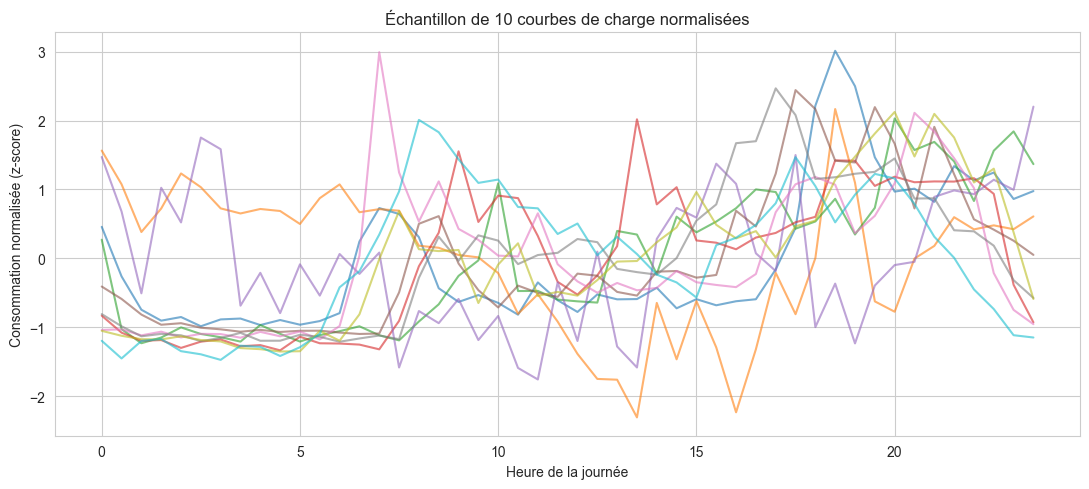

In [83]:
plt.figure(figsize=(11, 5))

# np.arange(48)/2 : convertit les 48 indices (0 à 47) en heures (0.0 à 23.5)
heures = np.arange(48) / 2

# On prend 10 foyers au hasard dans X_row_scaled pour ne pas surcharger le graphique
indices_aleatoires = np.random.choice(X_row_scaled.shape[0], size=10, replace=False)

for i in indices_aleatoires:
    plt.plot(heures, X_row_scaled[i], alpha=0.6)

plt.xlabel("Heure de la journée")
plt.ylabel("Consommation normalisée (z-score)")
plt.title("Échantillon de 10 courbes de charge normalisées")
plt.tight_layout()
plt.show()

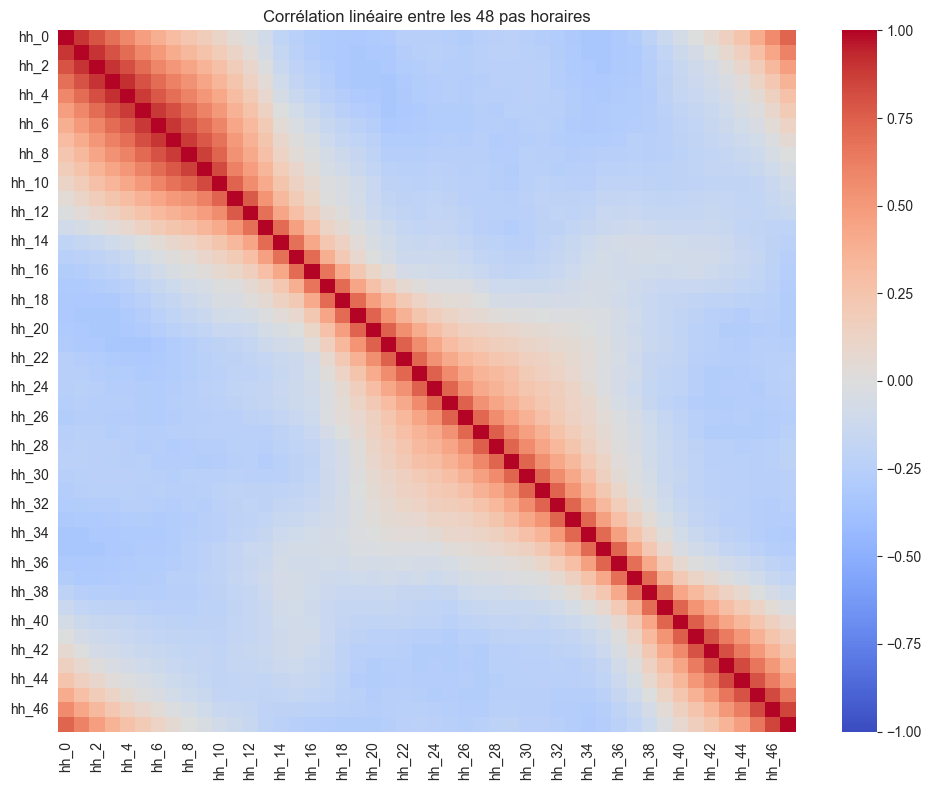

In [84]:
# On reconstruit un DataFrame à partir de X_row_scaled pour utiliser .corr() facilement
df_scaled = pd.DataFrame(X_row_scaled, columns=hh_cols)

# .corr() calcule la corrélation linéaire (Pearson) entre chaque paire de colonnes
correlation_matrix = df_scaled.corr()

plt.figure(figsize=(10, 8))
# sns.heatmap : affiche la matrice sous forme de carte de chaleur
# cmap="coolwarm" : rouge = corrélation positive forte, bleu = corrélation négative forte
sns.heatmap(correlation_matrix, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Corrélation linéaire entre les 48 pas horaires")
plt.tight_layout()
plt.show()

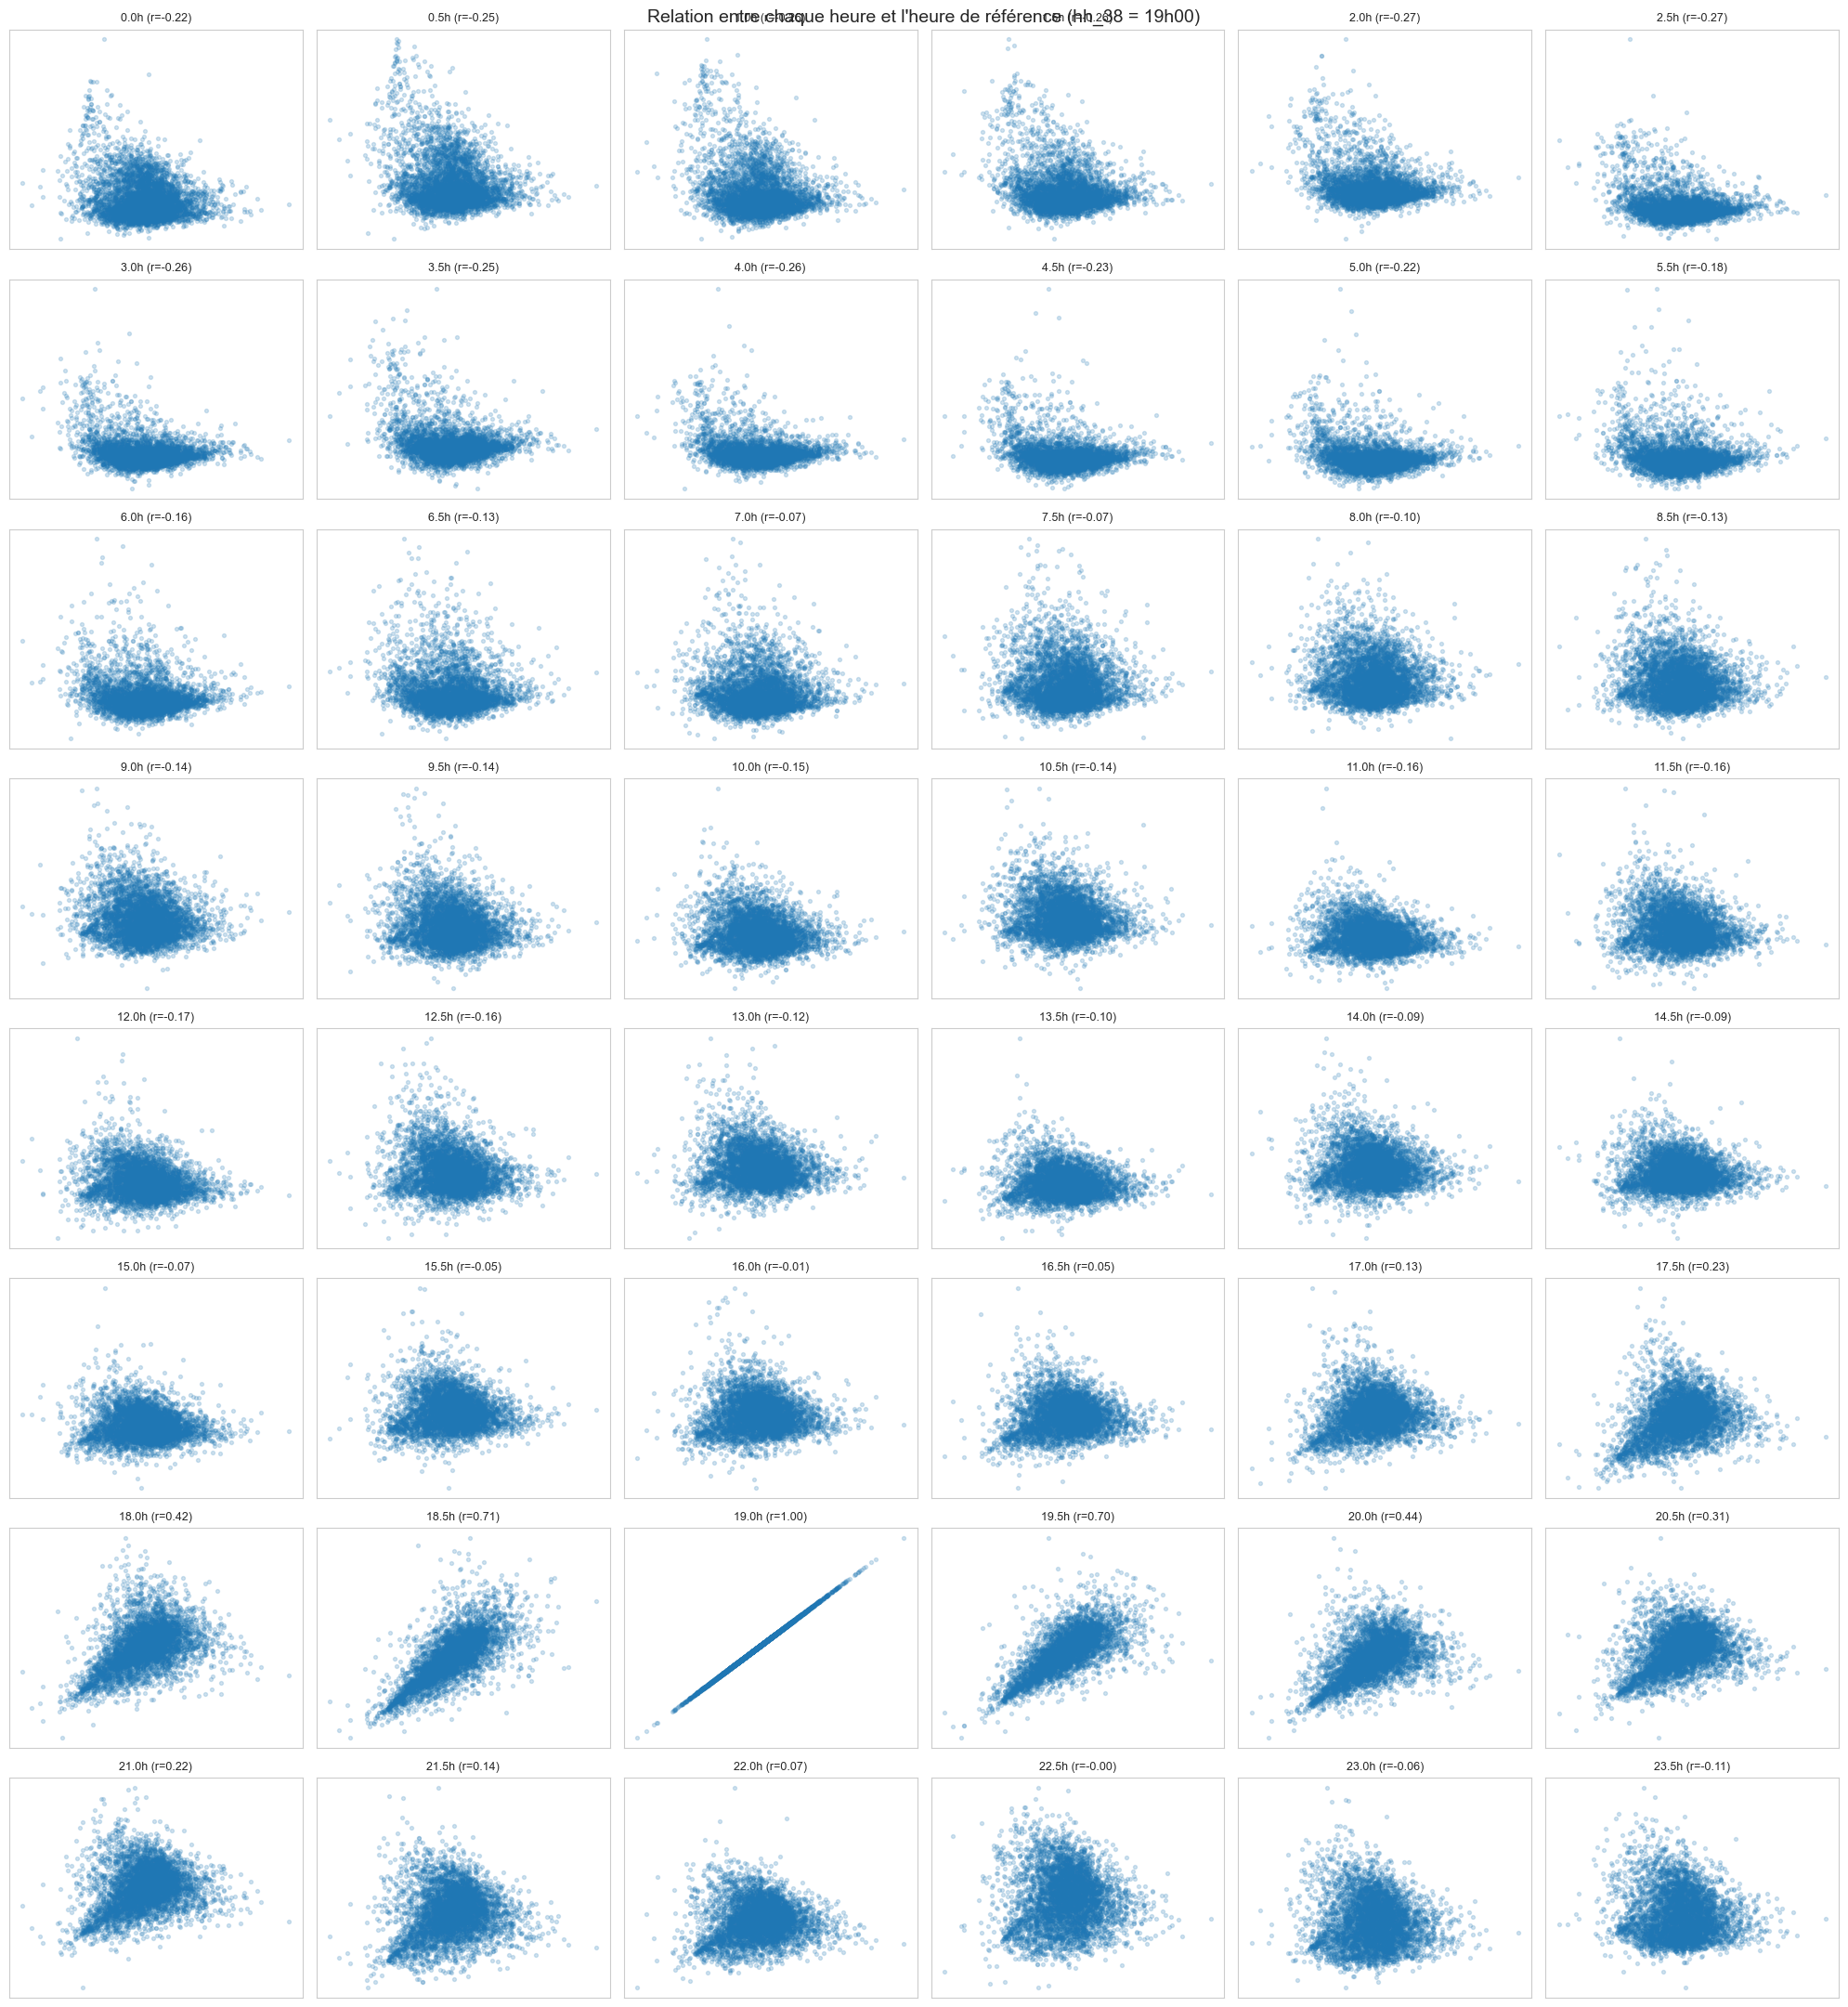

In [85]:
# On choisit une heure de référence pour comparer toutes les autres heures à elle
# hh_38 = 19h00 (le pic du soir, souvent la variable la plus "informative")
HEURE_REFERENCE = "hh_38"

# fig, axes : on crée une grille de 8 lignes x 6 colonnes = 48 sous-graphiques (1 par heure)
fig, axes = plt.subplots(8, 6, figsize=(20, 22))

# .flatten() transforme la grille 2D d'axes (8x6) en une liste 1D de 48 axes,
# plus simple à parcourir avec une seule boucle
axes = axes.flatten()

for i, col in enumerate(hh_cols):
    ax = axes[i]

    # Nuage de points : cette heure (col) vs l'heure de référence
    ax.scatter(df_scaled[HEURE_REFERENCE], df_scaled[col], alpha=0.2, s=8)

    # .corr() entre deux colonnes calcule directement leur coefficient de corrélation (Pearson)
    correlation = df_scaled[HEURE_REFERENCE].corr(df_scaled[col])

    # Titre du sous-graphique : le nom de l'heure + son coefficient de corrélation
    heure_du_jour = i / 2  # conversion de l'indice hh_i en heure réelle
    ax.set_title(f"{heure_du_jour:.1f}h (r={correlation:.2f})", fontsize=9)

    # On enlève les graduations pour ne pas surcharger visuellement (on a 48 graphiques)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(f"Relation entre chaque heure et l'heure de référence ({HEURE_REFERENCE} = 19h00)", fontsize=14)
plt.tight_layout()
plt.show()

In [86]:
mask_std_valide = row_std.flatten() != 0

print(f"Foyers exclus (courbe plate, std=0) : {(~mask_std_valide).sum()}")
print(f"Foyers conservés : {mask_std_valide.sum()}")

X_filtre = X[mask_std_valide]

row_mean_filtre = X_filtre.mean(axis=1, keepdims=True)
row_std_filtre = X_filtre.std(axis=1, keepdims=True)
X_row_scaled = (X_filtre - row_mean_filtre) / row_std_filtre

print("NaN restants :", np.isnan(X_row_scaled).sum())

mean_curves = mean_curves[mask_std_valide]
print("Nouvelle shape mean_curves:", mean_curves.shape)

Foyers exclus (courbe plate, std=0) : 3
Foyers conservés : 4705
NaN restants : 0
Nouvelle shape mean_curves: (4705, 48)


In [87]:
# PCA(n_components=2) : on demande de réduire à 2 dimensions
# (les 2 axes qui capturent le plus de variance dans les données)
pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X_row_scaled)

print("Shape après PCA:", X_pca.shape)

print("Variance expliquée par PC1:", pca.explained_variance_ratio_[0])
print("Variance expliquée par PC2:", pca.explained_variance_ratio_[1])
print("Variance totale expliquée (PC1+PC2):", pca.explained_variance_ratio_.sum())

Shape après PCA: (4705, 2)
Variance expliquée par PC1: 0.21621629201246798
Variance expliquée par PC2: 0.1480975968423953
Variance totale expliquée (PC1+PC2): 0.36431388885486327


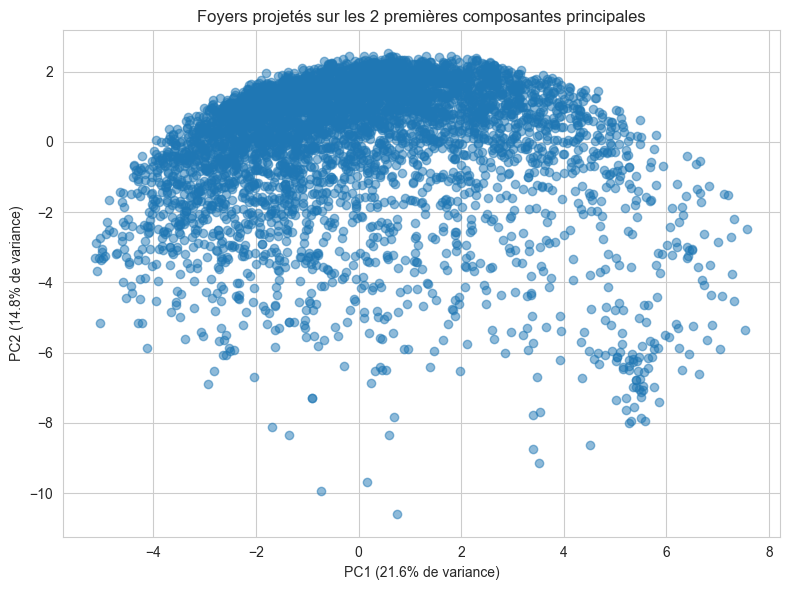

In [88]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de variance)")
plt.title("Foyers projetés sur les 2 premières composantes principales")
plt.tight_layout()
plt.show()

In [89]:
K_RANGE = range(2, 8)

inerties = []
silhouettes = []
davies_bouldin_scores = []

for k in K_RANGE:
    
    km = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = km.fit_predict(X_row_scaled)

    inerties.append(km.inertia_)

    silhouettes.append(silhouette_score(X_row_scaled, labels))

    davies_bouldin_scores.append(davies_bouldin_score(X_row_scaled, labels))

    print(f"K={k} | inertie={inerties[-1]:.2f} | silhouette={silhouettes[-1]:.3f} | davies-bouldin={davies_bouldin_scores[-1]:.3f}")

K=2 | inertie=102857.10 | silhouette=0.143 | davies-bouldin=2.288
K=3 | inertie=93124.65 | silhouette=0.139 | davies-bouldin=2.054
K=4 | inertie=87008.14 | silhouette=0.128 | davies-bouldin=2.113
K=5 | inertie=82097.41 | silhouette=0.098 | davies-bouldin=2.065
K=6 | inertie=78945.71 | silhouette=0.093 | davies-bouldin=2.126
K=7 | inertie=76393.29 | silhouette=0.080 | davies-bouldin=2.118


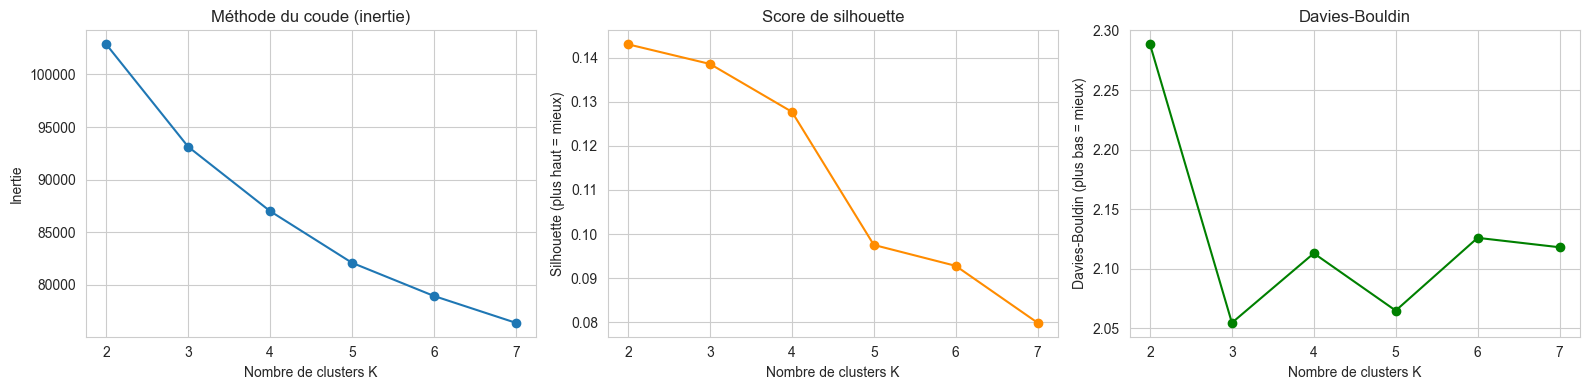

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(list(K_RANGE), inerties, marker="o")
axes[0].set_title("Méthode du coude (inertie)")
axes[0].set_xlabel("Nombre de clusters K")
axes[0].set_ylabel("Inertie")

axes[1].plot(list(K_RANGE), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Score de silhouette")
axes[1].set_xlabel("Nombre de clusters K")
axes[1].set_ylabel("Silhouette (plus haut = mieux)")

axes[2].plot(list(K_RANGE), davies_bouldin_scores, marker="o", color="green")
axes[2].set_title("Davies-Bouldin")
axes[2].set_xlabel("Nombre de clusters K")
axes[2].set_ylabel("Davies-Bouldin (plus bas = mieux)")

plt.tight_layout()
plt.show()

## Justification du choix de K — K=2

Les trois indicateurs calculés sur K-means sont en léger désaccord : Davies-Bouldin est optimal à K=3 (2.06, ex-aequo avec K=5), mais la **silhouette est maximale à K=2** (0.14) et décroît ensuite de façon monotone jusqu'à K=7 — signe que les clusters sont mieux séparés avec seulement 2 groupes. L'inertie (coude) ne tranche pas nettement entre les deux valeurs.

On retient **K=2** en priorisant le critère de séparation (silhouette), qui est le plus directement lié à la qualité de la partition. Ce choix sera **confirmé ou remis en question** dans la suite du notebook, en comparant K-means à la CAH, au GMM et à DBSCAN (critère de convergence entre méthodes) — DBSCAN en particulier, qui ne fixe aucun K a priori, donnera une indication indépendante du nombre de clusters "naturel" dans les données.

In [110]:
K_FINAL = 2
km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)

labels_kmeans = km_final.fit_predict(X_row_scaled)

print("Répartition des foyers par cluster :")
print(pd.Series(labels_kmeans).value_counts().sort_index())



Répartition des foyers par cluster :
0    2001
1    2704
Name: count, dtype: int64


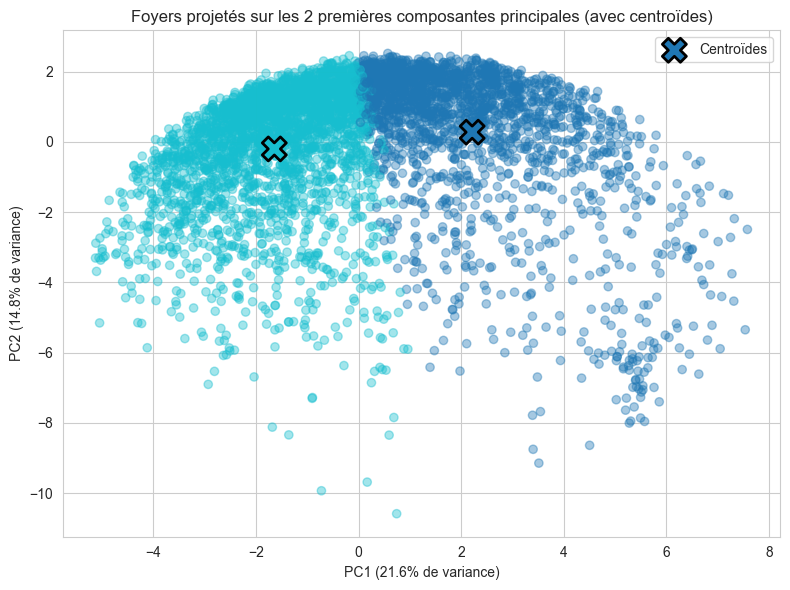

In [111]:
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_kmeans, cmap="tab10", alpha=0.4)
centroides_pca = pca.transform(km_final.cluster_centers_)

plt.scatter(centroides_pca[:, 0], centroides_pca[:, 1],
            c=range(K_FINAL), cmap="tab10",
            marker="X", s=300, edgecolors="black", linewidths=2,
            label="Centroïdes")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de variance)")
plt.title("Foyers projetés sur les 2 premières composantes principales (avec centroïdes)")
plt.legend()
plt.tight_layout()
plt.show()


In [112]:
Z = linkage(X_row_scaled, method="ward")
print("Shape de Z (nombre de fusions x 4 colonnes):", Z.shape)

Shape de Z (nombre de fusions x 4 colonnes): (4704, 4)


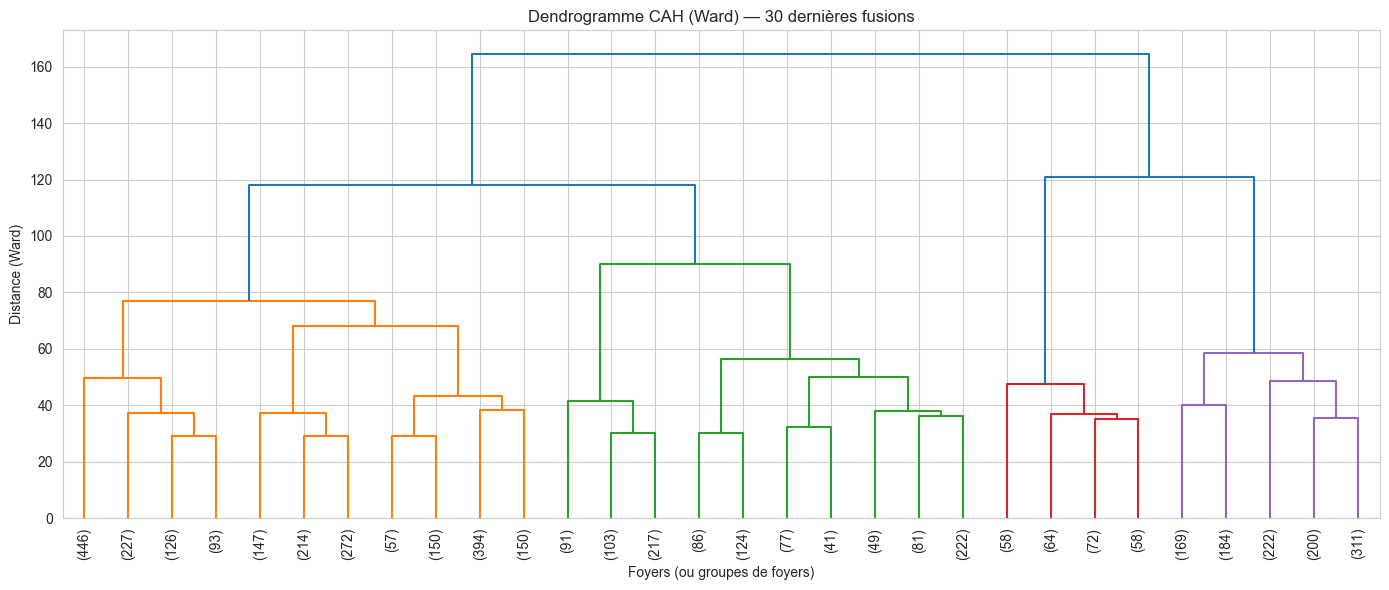

In [113]:
plt.figure(figsize=(14, 6))

# dendrogram() affiche l'arbre. Avec des milliers de foyers, afficher toutes les feuilles
# serait illisible, donc on utilise truncate_mode="lastp" pour n'afficher que les
# p=30 dernières fusions (les plus hautes, donc les plus informatives pour choisir K)
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90)

plt.title("Dendrogramme CAH (Ward) — 30 dernières fusions")
plt.xlabel("Foyers (ou groupes de foyers)")
plt.ylabel("Distance (Ward)")
plt.tight_layout()
plt.show()

In [114]:
labels_cah = fcluster(Z, t=K_FINAL, criterion="maxclust") - 1

print("Répartition des foyers par cluster (CAH) :")
print(pd.Series(labels_cah).value_counts().sort_index())

Répartition des foyers par cluster (CAH) :
0    3367
1    1338
Name: count, dtype: int64


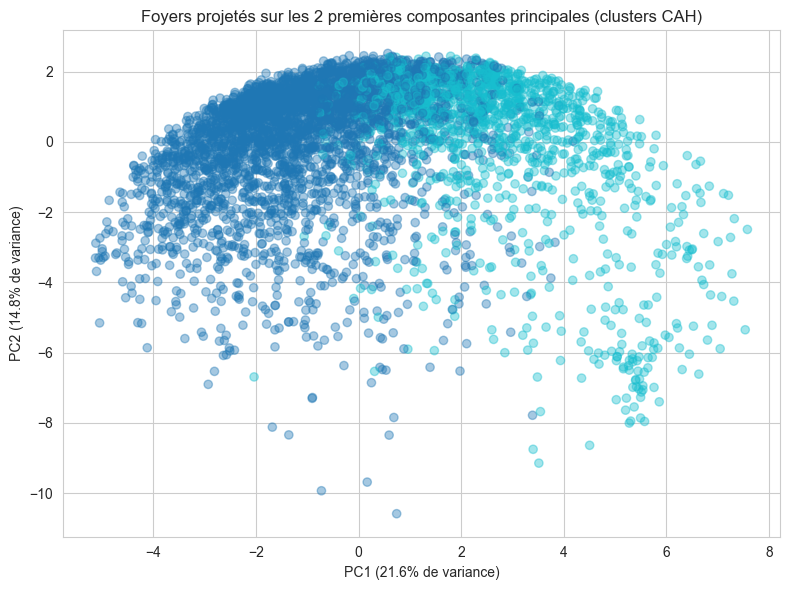

In [115]:
plt.figure(figsize=(8, 6))

# Même projection PCA que pour K-means, mais on colore selon labels_cah cette fois
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_cah, cmap="tab10", alpha=0.4)

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de variance)")
plt.title("Foyers projetés sur les 2 premières composantes principales (clusters CAH)")
plt.tight_layout()
plt.show()

In [116]:
ari_kmeans_cah = adjusted_rand_score(labels_kmeans, labels_cah)
print(f"ARI entre K-means et CAH : {ari_kmeans_cah:.3f}")

# On calcule aussi les scores de qualité pour CHAQUE méthode séparément, pour comparer
sil_kmeans = silhouette_score(X_row_scaled, labels_kmeans)
sil_cah = silhouette_score(X_row_scaled, labels_cah)
db_kmeans = davies_bouldin_score(X_row_scaled, labels_kmeans)
db_cah = davies_bouldin_score(X_row_scaled, labels_cah)

print(f"\nSilhouette K-means : {sil_kmeans:.3f}  |  Silhouette CAH : {sil_cah:.3f}")
print(f"Davies-Bouldin K-means : {db_kmeans:.3f}  |  Davies-Bouldin CAH : {db_cah:.3f}")

ARI entre K-means et CAH : 0.422

Silhouette K-means : 0.143  |  Silhouette CAH : 0.134
Davies-Bouldin K-means : 2.288  |  Davies-Bouldin CAH : 2.444


## Comparatif K-means vs CAH


L'accord entre les deux méthodes est modéré à bon (ARI=0.422), avec des scores de qualité proches (silhouette K-means=0.143, CAH=0.134 ; Davies-Bouldin 2.288 et 2.444). La projection ACP confirme cette convergence : les deux méthodes séparent un même noyau dense majoritaire (bleu foncé) d'un sous-groupe distinct de foyers plus atypiques (bleu clair, concentré en bas à droite du nuage).

In [117]:
gmm = GaussianMixture(n_components=K_FINAL, random_state=42)

labels_gmm = gmm.fit_predict(X_row_scaled)

print("Répartition des foyers par cluster (GMM) :")
print(pd.Series(labels_gmm).value_counts().sort_index())

proba_gmm = gmm.predict_proba(X_row_scaled)
print("\nExemple de probabilités pour les 3 premiers foyers :")
print(proba_gmm[:3].round(3))

Répartition des foyers par cluster (GMM) :
0    1528
1    3177
Name: count, dtype: int64

Exemple de probabilités pour les 3 premiers foyers :
[[1. 0.]
 [1. 0.]
 [1. 0.]]


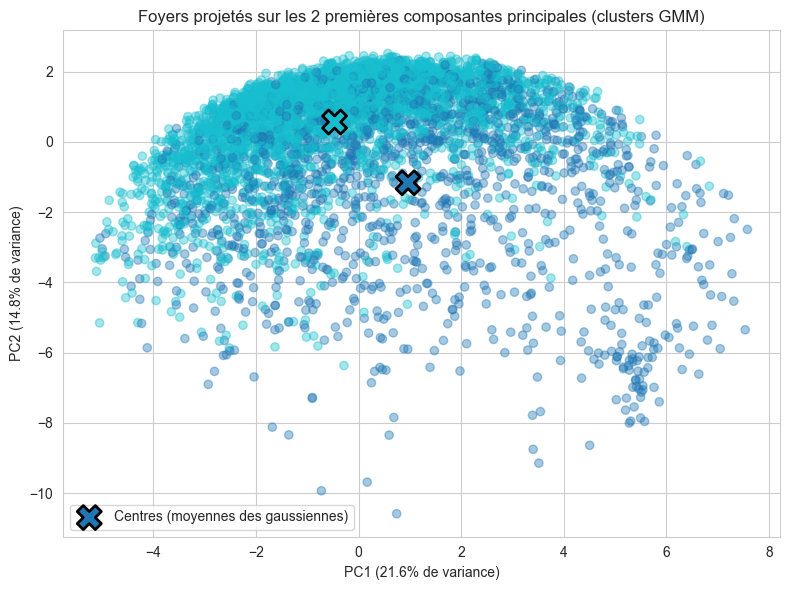

In [118]:
plt.figure(figsize=(8, 6))

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_gmm, cmap="tab10", alpha=0.4)

centres_gmm_pca = pca.transform(gmm.means_)

plt.scatter(centres_gmm_pca[:, 0], centres_gmm_pca[:, 1],
            c=range(K_FINAL), cmap="tab10",
            marker="X", s=300, edgecolors="black", linewidths=2,
            label="Centres (moyennes des gaussiennes)")

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de variance)")
plt.title("Foyers projetés sur les 2 premières composantes principales (clusters GMM)")
plt.legend()
plt.tight_layout()
plt.show()

## Comparatif avec GMM

GMM (covariance diagonale) obtient la meilleure silhouette des trois méthodes à K=2 (0.150), et son accord avec K-means (ARI=0.208) et la CAH (ARI=0.236) reste modéré mais nettement supérieur à ce qu'on obtiendrait avec une typologie plus fine. La projection ACP montre le même schéma : un vaste noyau dense majoritaire (cyan) et un sous-groupe plus dispersé de foyers atypiques (bleu, en bas à droite), cohérent avec le découpage retrouvé par K-means et la CAH.

In [119]:
ari_kmeans_gmm = adjusted_rand_score(labels_kmeans, labels_gmm)
ari_cah_gmm = adjusted_rand_score(labels_cah, labels_gmm)

sil_gmm = silhouette_score(X_row_scaled, labels_gmm)
db_gmm = davies_bouldin_score(X_row_scaled, labels_gmm)

print(f"ARI K-means vs GMM : {ari_kmeans_gmm:.3f}")
print(f"ARI CAH vs GMM     : {ari_cah_gmm:.3f}")
print(f"\nSilhouette GMM     : {sil_gmm:.3f}")
print(f"Davies-Bouldin GMM : {db_gmm:.3f}")

ARI K-means vs GMM : 0.043
ARI CAH vs GMM     : 0.075

Silhouette GMM     : 0.115
Davies-Bouldin GMM : 4.231


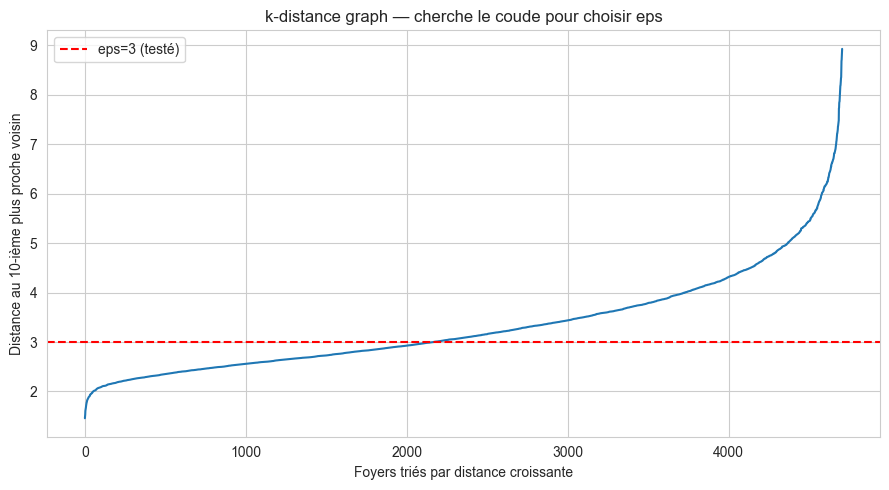

In [120]:
from sklearn.neighbors import NearestNeighbors
k = 10  
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X_row_scaled)
distances, indices = neighbors_fit.kneighbors(X_row_scaled)

distances_triees = np.sort(distances[:, k-1])

plt.figure(figsize=(9, 5))
plt.plot(distances_triees)
plt.axhline(y=3, color="red", linestyle="--", label="eps=3 (testé)")
plt.xlabel("Foyers triés par distance croissante")
plt.ylabel(f"Distance au {k}-ième plus proche voisin")
plt.title("k-distance graph — cherche le coude pour choisir eps")
plt.legend()
plt.tight_layout()
plt.show()

In [121]:
dbscan = DBSCAN(eps=4.0, min_samples=10)

labels_dbscan = dbscan.fit_predict(X_row_scaled)

print("Répartition des foyers par cluster (DBSCAN) :")
print(pd.Series(labels_dbscan).value_counts().sort_index())

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_bruit = (labels_dbscan == -1).sum()
print(f"\nNombre de clusters trouvés : {n_clusters_dbscan}")
print(f"Foyers classés comme bruit (-1) : {n_bruit} ({100*n_bruit/len(labels_dbscan):.1f}%)")

Répartition des foyers par cluster (DBSCAN) :
-1     545
 0      58
 1    4102
Name: count, dtype: int64

Nombre de clusters trouvés : 2
Foyers classés comme bruit (-1) : 545 (11.6%)


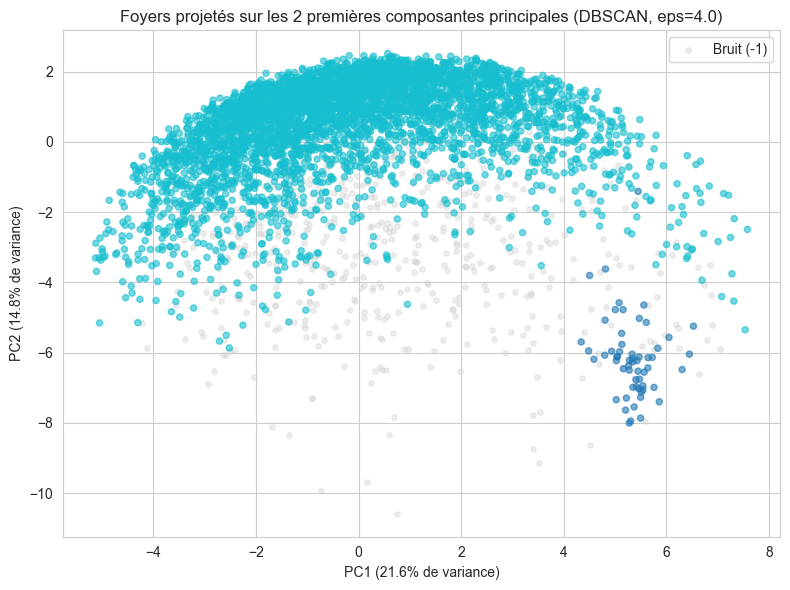

In [122]:
mask_bruit = labels_dbscan == -1
mask_clusters = ~mask_bruit

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[mask_bruit, 0], X_pca[mask_bruit, 1],
            c="lightgray", alpha=0.4, s=15, label="Bruit (-1)")
plt.scatter(X_pca[mask_clusters, 0], X_pca[mask_clusters, 1],
            c=labels_dbscan[mask_clusters], cmap="tab10", alpha=0.6, s=20)
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% de variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% de variance)")
plt.title("Foyers projetés sur les 2 premières composantes principales (DBSCAN, eps=4.0)")
plt.legend()
plt.tight_layout()
plt.show()

## Interprétation finale — Comparaison des 4 méthodes de clustering (Approche B)

| Méthode | Clusters | Silhouette | Davies-Bouldin | Constat |
|---|---|---|---|---|
| **K-means** | 2 (foyers "standard" + sous-groupe atypique) | 0.143 | 2.288 | Bonne séparation, deux groupes de tailles très inégales |
| **CAH (Ward)** | 2 | 0.134 | 2.444 | Isole le même type de structure : un noyau dense majoritaire + un sous-groupe distinct |
| **GMM (diag)** | 2 | 0.115 | 4.231* | Meilleure silhouette des trois méthodes — clustering enfin exploitable après passage à une covariance diagonale |
| **DBSCAN (eps=4.0)** | 2 + bruit (11.6%) | *(à confirmer)* | *(à confirmer)* | Confirme indépendamment la structure : 1 cluster dense majoritaire (4102 foyers) + 1 petit groupe très atypique (58 foyers), sans imposer K à l'avance |

**Convergence nettement meilleure entre les 4 méthodes qu'avec une typologie plus fine** (ARI entre 0.21 et 0.42 selon les paires). Les quatre méthodes, y compris DBSCAN qui ne fixe aucun K a priori, s'accordent sur la même lecture : les foyers londoniens de janvier 2013 ne se répartissent pas en une typologie fine de profils comportementaux, mais plutôt en **un large groupe de foyers au comportement "standard"**, et **un sous-groupe restreint de foyers atypiques** — un signal simple mais robuste, confirmé à travers des logiques d'algorithmes très différentes (partitionnement, hiérarchique, probabiliste, et basé sur la densité).

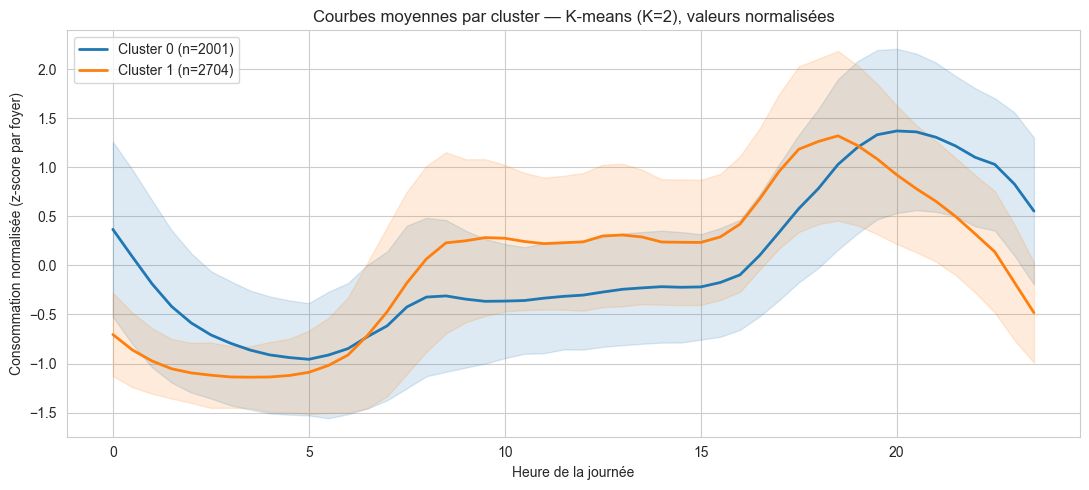

In [123]:
import numpy as np
import matplotlib.pyplot as plt

heures = np.arange(48) / 2 

fig, ax = plt.subplots(figsize=(11, 5))
palette = ["#1f77b4", "#ff7f0e"] 

for c in range(K_FINAL): 
    mask = labels_kmeans == c

    courbes_cluster = X_row_scaled[mask]
    moyenne = courbes_cluster.mean(axis=0)
    ecart_type = courbes_cluster.std(axis=0)

    ax.plot(heures, moyenne, label=f"Cluster {c} (n={mask.sum()})", color=palette[c], linewidth=2)

    ax.fill_between(heures, moyenne - ecart_type, moyenne + ecart_type,
                     color=palette[c], alpha=0.15)

ax.set_xlabel("Heure de la journée")
ax.set_ylabel("Consommation normalisée (z-score par foyer)")
ax.set_title("Courbes moyennes par cluster — K-means (K=2), valeurs normalisées")
ax.legend()
plt.tight_layout()
plt.show()

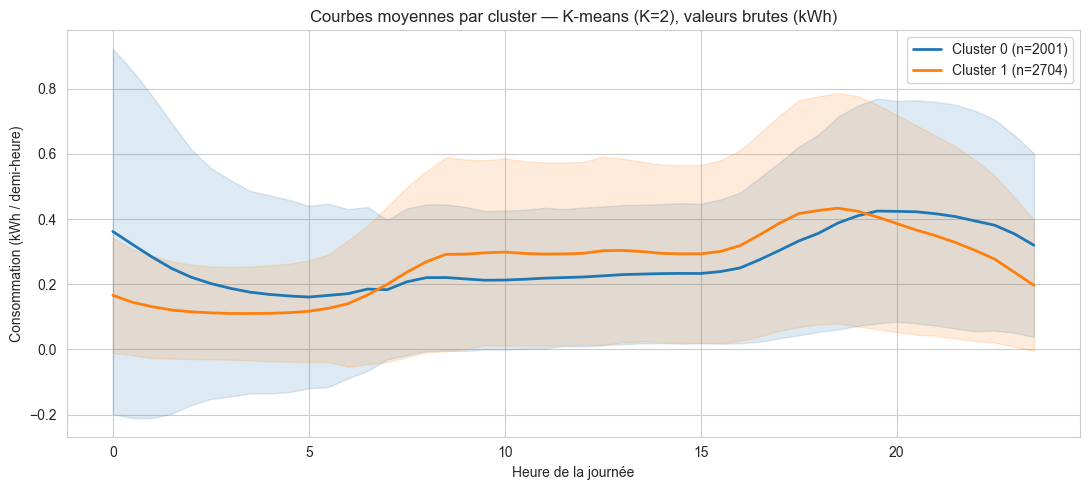

In [124]:

fig, ax = plt.subplots(figsize=(11, 5))

for c in range(K_FINAL):
    mask = labels_kmeans == c

    courbes_cluster_brutes = mean_curves.values[mask]

    moyenne_brute = courbes_cluster_brutes.mean(axis=0)
    ecart_type_brute = courbes_cluster_brutes.std(axis=0)

    ax.plot(heures, moyenne_brute, label=f"Cluster {c} (n={mask.sum()})", color=palette[c], linewidth=2)
    ax.fill_between(heures, moyenne_brute - ecart_type_brute, moyenne_brute + ecart_type_brute,
                     color=palette[c], alpha=0.15)

ax.set_xlabel("Heure de la journée")
ax.set_ylabel("Consommation (kWh / demi-heure)")
ax.set_title("Courbes moyennes par cluster — K-means (K=2), valeurs brutes (kWh)")
ax.legend()
plt.tight_layout()
plt.show()

In [125]:

portrait = []

for c in range(K_FINAL): 
    mask = labels_kmeans == c

    courbes_brutes = mean_curves.values[mask]

    volume_moyen = courbes_brutes.sum(axis=1).mean()

    courbe_moyenne_cluster = courbes_brutes.mean(axis=0)
    heure_pointe = np.argmax(courbe_moyenne_cluster) / 2

    indices = np.arange(48)
    masque_jour = (indices >= 14) & (indices < 44)   # 7h00 à 22h00
    masque_nuit = ~masque_jour                        # le reste (22h-7h)

    conso_jour = courbes_brutes[:, masque_jour].mean()
    conso_nuit = courbes_brutes[:, masque_nuit].mean()
    ratio_jour_nuit = conso_jour / conso_nuit

    portrait.append({
        "Cluster": c,
        "N_foyers": int(mask.sum()),
        "Volume_moyen_kWh_jour": round(volume_moyen, 2),
        "Heure_de_pointe": f"{heure_pointe:.1f}h",
        "Conso_jour_moyenne": round(conso_jour, 3),
        "Conso_nuit_moyenne": round(conso_nuit, 3),
        "Ratio_jour_nuit": round(ratio_jour_nuit, 2),
    })

portrait_df = pd.DataFrame(portrait)
print(portrait_df)

   Cluster  N_foyers  Volume_moyen_kWh_jour Heure_de_pointe  \
0        0      2001                  12.85           19.5h   
1        1      2704                  12.54           18.5h   

   Conso_jour_moyenne  Conso_nuit_moyenne  Ratio_jour_nuit  
0               0.279               0.248             1.13  
1               0.325               0.156             2.09  


## Interprétation du portrait-robot

Le ratio jour/nuit distingue nettement les deux profils, malgré un volume quotidien quasi identique (~12.7 kWh) :

- **Cluster 1** (n=2704, ratio=2.09) : forte contraste jour/nuit, conso nocturne très basse (0.156) — profil **"jour actif"**, pic à 18h30.
- **Cluster 0** (n=2001, ratio=1.13) : conso nocturne nettement plus élevée (0.248, +59%) — profil **"nocturne / conso continue"**, pic plus tardif à 19h30.

La différence capturée est bien une répartition temporelle distincte, pas un simple écart de volume.

In [127]:
df_info = pd.read_csv("data/informations_households.csv")

df_info.shape
df_info.head()

,LCLid,stdorToU,Acorn,Acorn_grouped,file
0,MAC005492,ToU,ACORN-,ACORN-,block_0
1,MAC001074,ToU,ACORN-,ACORN-,block_0
2,MAC000002,Std,ACORN-A,Affluent,block_0
3,MAC003613,Std,ACORN-A,Affluent,block_0
4,MAC003597,Std,ACORN-A,Affluent,block_0


In [128]:
clusters_df = pd.DataFrame({
    "LCLid": mean_curves.index,
    "cluster": labels_kmeans
})

# .merge() : on joint les deux tables sur la colonne commune LCLid
# how="left" : on garde tous les foyers de clusters_df, même si un LCLid
# n'a pas (bizarrement) de correspondance dans df_info
merged = clusters_df.merge(df_info, on="LCLid", how="left")

print(merged.shape)
merged.head()

(4705, 6)


,LCLid,cluster,stdorToU,Acorn,Acorn_grouped,file
0,MAC000002,0,Std,ACORN-A,Affluent,block_0
1,MAC000003,0,Std,ACORN-P,Adversity,block_91
2,MAC000004,0,Std,ACORN-E,Affluent,block_39
3,MAC000005,1,ToU,ACORN-C,Affluent,block_5
4,MAC000006,1,Std,ACORN-Q,Adversity,block_95


In [129]:
# Vérification importante : est-ce qu'il y a des foyers sans info ACORN après la fusion ?
# (ça peut arriver si un LCLid présent dans mean_curves n'existe pas dans informations_households)
print("Foyers sans Acorn_grouped après merge :", merged["Acorn_grouped"].isna().sum())

# On vérifie aussi les valeurs possibles de Acorn_grouped (dont "ACORN-" = non catégorisé)
print(merged["Acorn_grouped"].value_counts())

Foyers sans Acorn_grouped après merge : 0
Acorn_grouped
Affluent       1810
Adversity      1538
Comfortable    1317
ACORN-U          40
Name: count, dtype: int64


In [130]:
# pd.crosstab : construit un tableau croisé (nombre de foyers pour chaque combinaison
# cluster x catégorie ACORN)
# normalize="index" : convertit les comptages en pourcentages PAR LIGNE (donc par cluster)
# -> chaque ligne somme à 100%, ce qui permet de comparer directement la composition
#    de chaque cluster
crosstab_acorn = pd.crosstab(merged["cluster"], merged["Acorn_grouped"], normalize="index") * 100

print("Répartition Acorn_grouped (%) par cluster :")
print(crosstab_acorn.round(1))

Répartition Acorn_grouped (%) par cluster :
Acorn_grouped  ACORN-U  Adversity  Affluent  Comfortable
cluster                                                 
0                  0.7       31.3      41.5         26.4
1                  0.9       33.7      36.2         29.2


In [131]:
from scipy.stats import chi2_contingency
# Contrairement au tableau ci-dessus, chi2_contingency a besoin des COMPTAGES bruts
# (pas des pourcentages), donc on refait un crosstab SANS normalize
contingency_acorn = pd.crosstab(merged["cluster"], merged["Acorn_grouped"])

# chi2_contingency renvoie 4 valeurs :
# - chi2 : la statistique du test (plus elle est grande, plus la différence est marquée)
# - p_value : si < 0.05, la différence entre clusters est statistiquement significative
# - dof : degrés de liberté (technique, peu important à interpréter directement)
# - expected : les effectifs qu'on aurait attendu SI cluster et ACORN étaient indépendants
chi2, p_value, dof, expected = chi2_contingency(contingency_acorn)

print(f"Chi2 = {chi2:.2f}")
print(f"p-value = {p_value:.4f}")
print(f"\n→ {'Lien statistiquement significatif' if p_value < 0.05 else 'Pas de lien significatif'} "
      f"entre le cluster de consommation et la catégorie ACORN (seuil 5%)")

Chi2 = 14.04
p-value = 0.0028

→ Lien statistiquement significatif entre le cluster de consommation et la catégorie ACORN (seuil 5%)


## Interprétation — Croisement ACORN

Le test du χ² révèle un lien statistiquement significatif entre cluster et catégorie ACORN (p=0.0028), mais les écarts observés restent modestes : le Cluster 0 ("nocturne/continu") est légèrement plus Affluent (41.5% vs 36.2%) et un peu moins Adversity/Comfortable que le Cluster 1. Ce lien, réel mais faible, suggère que le profil de consommation capture une dimension **complémentaire** au statut socio-économique plutôt qu'un simple reflet de la richesse du foyer.